In [17]:
import os
os.chdir('/Users/jeffreybloodworth/Desktop/git-repos/scRNAseq-ExplainableML')
os.getcwd()

'/Users/jeffreybloodworth/Desktop/git-repos/scRNAseq-ExplainableML'

In [30]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [19]:
X = pd.read_csv(
    "data/processed/ml_matrix_top2000.csv.gz",
    index_col=0
)

meta = pd.read_csv(
    "data/processed/pdc_metadata.csv"
)

print(X.shape)
print(meta.shape)

(4846, 2000)
(14430, 58)


In [20]:
meta_rf = meta[
    meta["cell"].isin(X.index)
].copy()

In [21]:
meta_rf = (
    meta_rf
    .set_index("cell")
    .loc[X.index]
    .reset_index()
)

In [22]:
if "index" in meta_rf.columns:
    meta_rf = meta_rf.rename(
        columns={"index": "cell"}
    )

In [23]:
print(X.shape)
print(meta_rf.shape)

meta_rf["is_malignant"].value_counts()

(4846, 2000)
(4846, 58)


is_malignant
Malignant       4405
Premalignant     441
Name: count, dtype: int64

In [24]:
y = meta_rf["is_malignant"].map({
    "Premalignant": 0,
    "Malignant": 1
})

print(y.value_counts())

is_malignant
1    4405
0     441
Name: count, dtype: int64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3876, 2000)
(970, 2000)


In [28]:
X_shap = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

In [32]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'
,feature_types,None


In [34]:

explainer = shap.TreeExplainer(xgb)

X_shap = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(
    X_shap
)


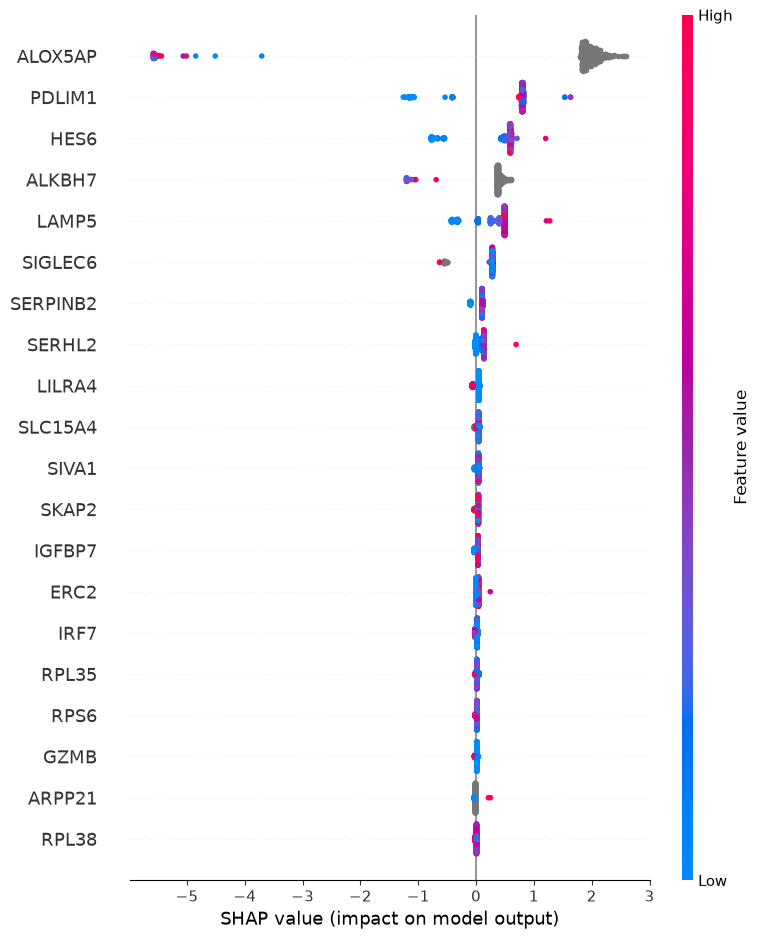

In [35]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

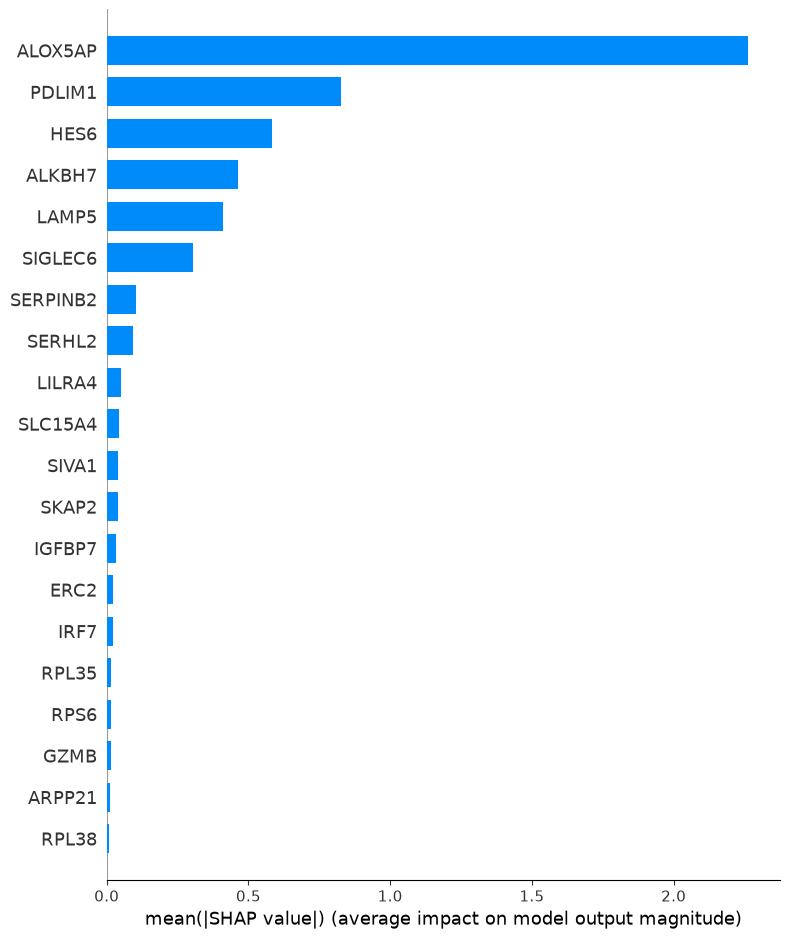

In [36]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

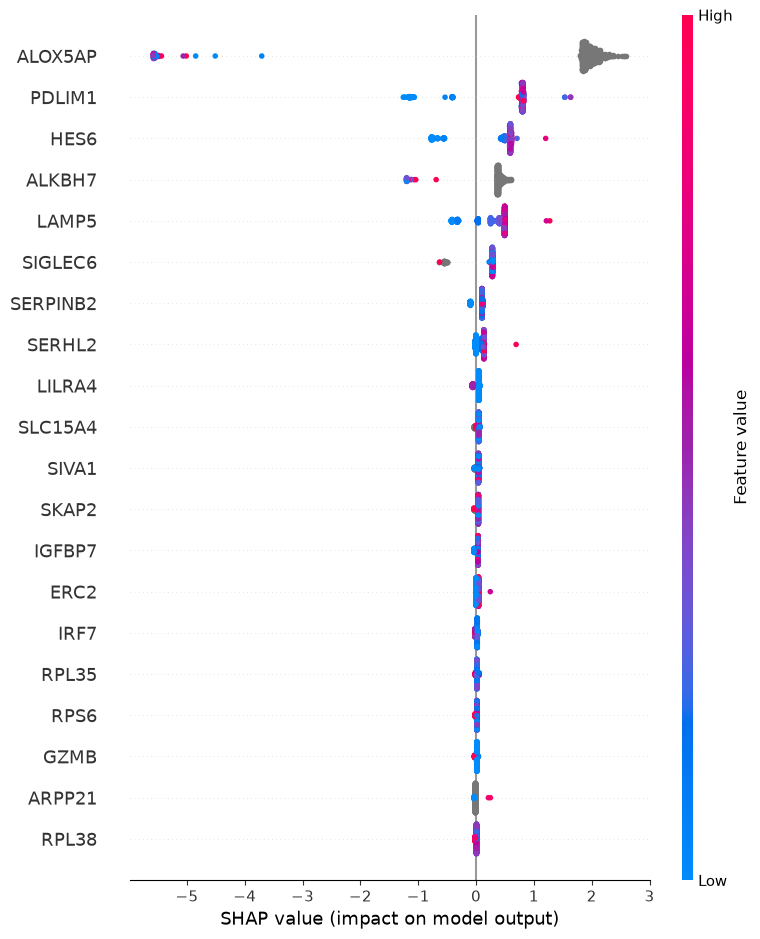

In [37]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

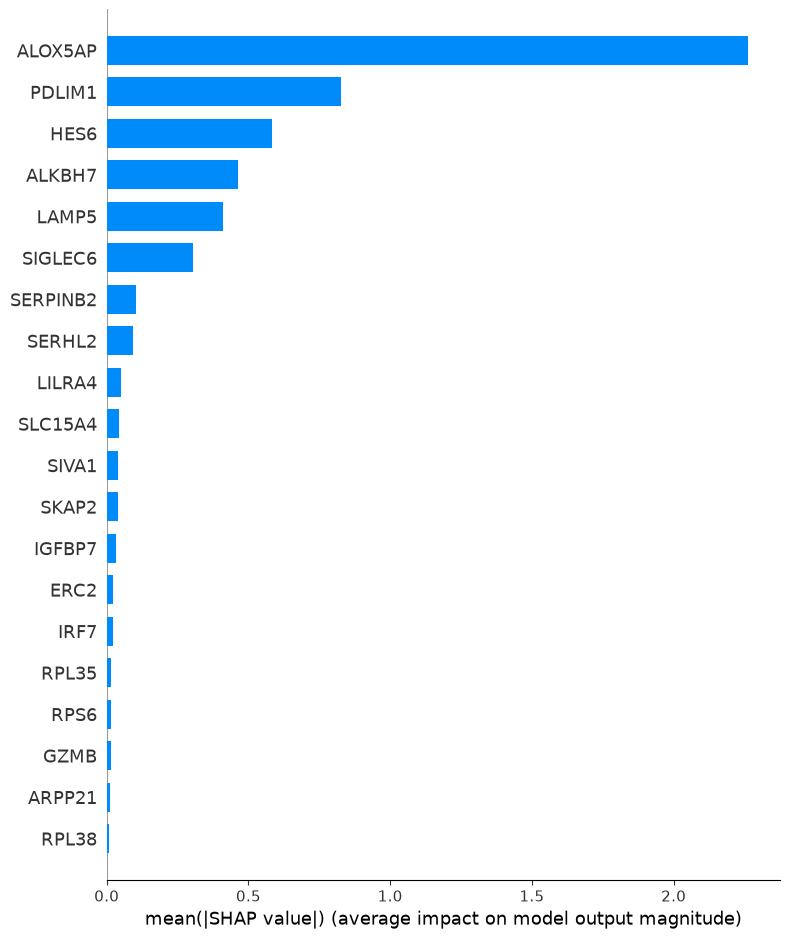

In [38]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

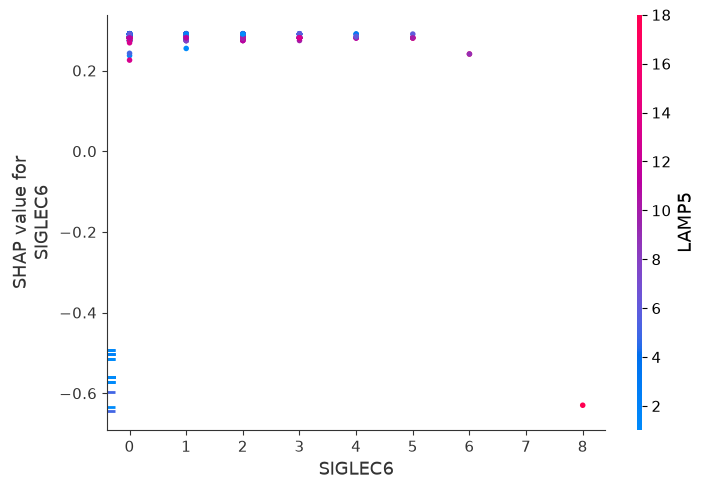

In [39]:
shap.dependence_plot(
    "SIGLEC6",
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_SIGLEC6_dependence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

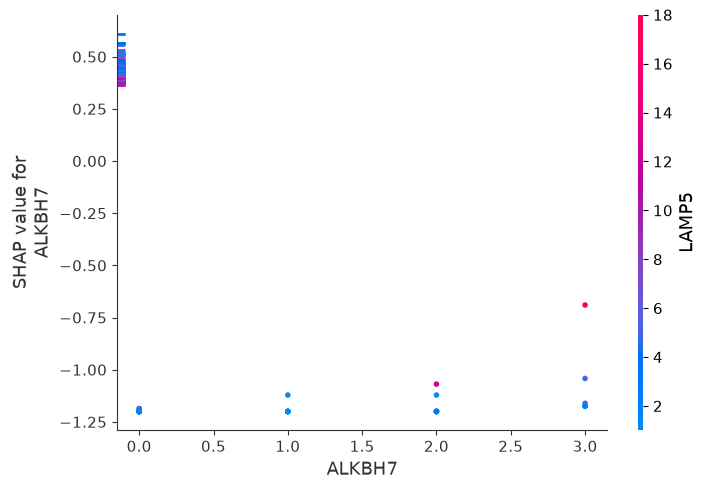

In [40]:
shap.dependence_plot(
    "ALKBH7",
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_ALKBH7_dependence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

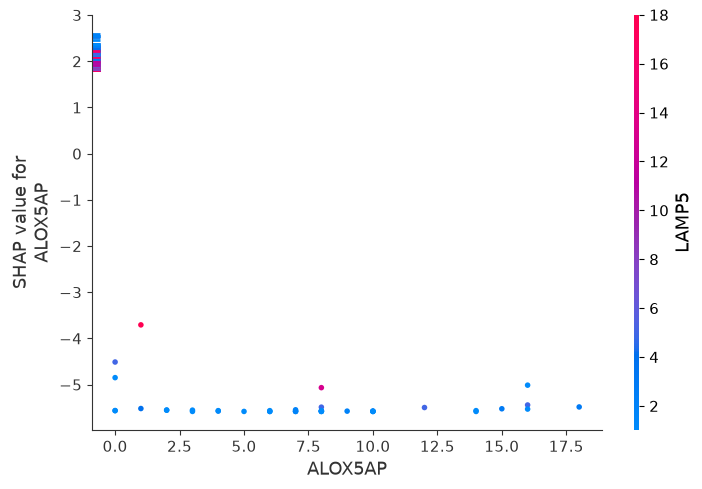

In [41]:
shap.dependence_plot(
    "ALOX5AP",
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_ALOX5AP_dependence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

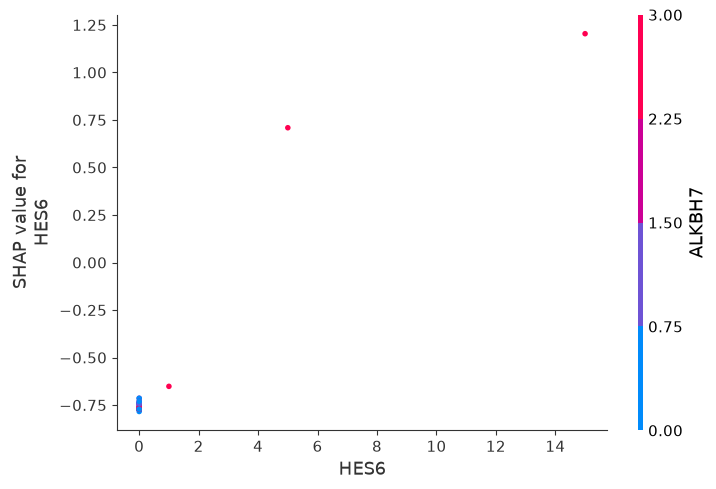

In [42]:
shap.dependence_plot(
    "HES6",
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_HES6_dependence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

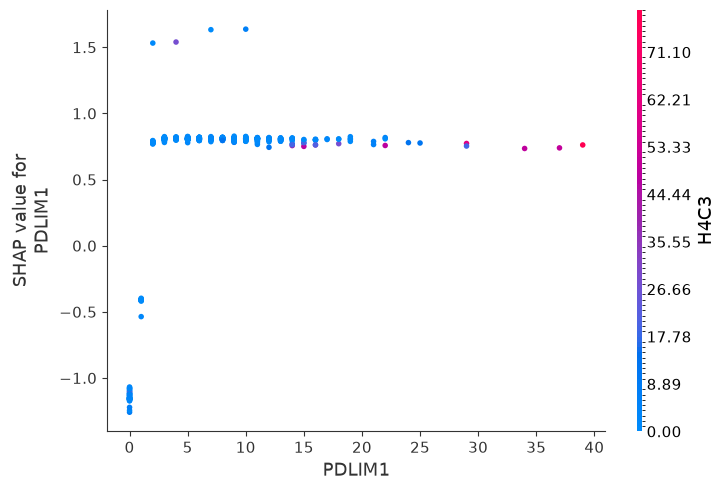

In [43]:
shap.dependence_plot(
    "PDLIM1",
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_PDLIM1_dependence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
from pathlib import Path

Path("figures").mkdir(
    exist_ok=True
)

In [45]:
import pandas as pd
import numpy as np

shap_importance = pd.DataFrame({
    "gene": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance.to_csv(
    "results/shap_importance.csv",
    index=False
)

In [46]:
shap_importance.head(20)

,gene,mean_abs_shap
238,ALOX5AP,2.261935
190,PDLIM1,0.826139
159,HES6,0.584516
1555,ALKBH7,0.464363
174,LAMP5,0.410710
1546,SIGLEC6,0.303552
123,SERPINB2,0.104219
647,SERHL2,0.092326
1751,LILRA4,0.049683
1353,SLC15A4,0.043718
